# Verifaction Notebook 1
## Master Algorithm Comparison

## Implementation

We use four components:

- **ConstantSource**: provides a constant reference `r`
- **Gain**: direct feedthrough, `y = k * u`
- **Subtractor**: direct feedthrough, `diff = pos - neg`
- **Integrator**: dynamic state, integrates its input

The resulting system implements:

$$
\dot{y} = k r - y
$$

with solution (for `y(0)=0`):

$$
y(t) = k r \,(1 - e^{-t})
$$


In [1]:
import numpy as np

from syssimx import CoSimComponent, Connection, System
from syssimx.core import PortSpec, PortType
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer
from syssimx.system.algorithms import JacobiAlgorithm, GaussSeidelAlgorithm, IJCSAAlgorithm

from plot_setup import set_professional_style, FULL_WIDTH, HALF_WIDTH, SUBFIG_048
plt = set_professional_style(latex=True, fontsize=10, savefig_format="svg")

In [2]:
class ConstantSource(CoSimComponent):
    """A source component that outputs a constant value."""

    def __init__(self, name: str, value: float = 1.0):
        super().__init__(name, group="Source")
        self.value = value
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t: float | None = None, event_names=None):
        self.outputs["y"].set(self.value, t)

class Gain(CoSimComponent):
    """Simple gain component: y = k * u"""

    def __init__(self, name: str, gain: float = 1.0):
        super().__init__(name, group="Gain")
        self.k = gain
        self.input_specs.update({"u": PortSpec(name="u", type=PortType.REAL, direction="in")})
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def evaluate_outputs(self, inputs, t=None):
        self.set_inputs(inputs, t=t)
        self._update_output_states(t)
        return self.get_outputs()

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t):
        y = self.k * self.inputs["u"].get()
        self.outputs["y"].set(y, t)

class Subtractor(CoSimComponent):
    """diff = pos - neg"""

    def __init__(self, name="Subtractor"):
        super().__init__(name, group="Subtractor")
        self.input_specs.update({
            "pos": PortSpec("pos", PortType.REAL, direction="in"),
            "neg": PortSpec("neg", PortType.REAL, direction="in"),
        })
        self.output_specs.update({"diff": PortSpec("diff", PortType.REAL, direction="out")})

    def _initialize_component(self, t0: float) -> None:
        pass

    def _do_step_internal(self, t: float, dt: float) -> None:
        pass

    def _update_output_states(self, t):
        diff = self.inputs["pos"].get() - self.inputs["neg"].get()
        self.outputs["diff"].set(diff, t)

    def evaluate_outputs(self, inputs) -> dict:
        i1 = inputs.get("pos", self.inputs["pos"].get())
        i2 = inputs.get("neg", self.inputs["neg"].get())
        self.outputs["diff"].set(i1 - i2, None)
        return {"diff": i1 - i2}
    
class Integrator(CoSimComponent):
    """Integrator with explicit Euler stepping."""

    def __init__(self, name="Integrator", x0=0.0):
        super().__init__(name, group="Integrator")
        self.input_specs.update({"u": PortSpec(name="u", type=PortType.REAL, direction="in")})
        self.output_specs.update({"y": PortSpec(name="y", type=PortType.REAL, direction="out")})
        self.x0 = x0

    def _initialize_component(self, t0: float) -> None:
        self.x = self.x0

    def _do_step_internal(self, t: float, dt: float) -> None:
        u = self.inputs["u"].get()
        self.x += u * dt

    def _update_output_states(self, t):
        self.outputs["y"].set(self.x, t)

    def reset(self):
        super().reset()
        self.x = self.x0
        self._update_output_states(self.t)

def build_components(k=1.0, r=1.0):
    source = ConstantSource("Source", value=r)
    gain = Gain("Gain", gain=k)
    subtractor = Subtractor("Subtractor")
    integrator = Integrator("Integrator", x0=0.0)
    return source, gain, subtractor, integrator


def build_connections(source, gain, subtractor, integrator):
    return [
        Connection(src_comp=source.name, src_port=source.output_specs["y"].name,
                   dst_comp=gain.name, dst_port=gain.input_specs["u"].name),
        Connection(src_comp=gain.name, src_port=gain.output_specs["y"].name,
                   dst_comp=subtractor.name, dst_port=subtractor.input_specs["pos"].name),
        Connection(src_comp=integrator.name, src_port=integrator.output_specs["y"].name,
                   dst_comp=subtractor.name, dst_port=subtractor.input_specs["neg"].name),
        Connection(src_comp=subtractor.name, src_port=subtractor.output_specs["diff"].name,
                   dst_comp=integrator.name, dst_port=integrator.input_specs["u"].name),
    ]


source, gain, subtractor, integrator = build_components(k=1.0, r=1.0)
connections = build_connections(source, gain, subtractor, integrator)

base_system = System(name="ExecutionOrderDemo")
for comp in [source, gain, subtractor, integrator]:
    base_system.add_component(comp)
for conn in connections:
    base_system.add_connection(conn)

base_system.initialize(t0=0.0)
print("Execution order:", base_system.execution_order)

Execution order: [['Integrator', 'Source'], ['Gain'], ['Subtractor']]


In [3]:
def run_with_algorithm(algorithm, dt, k=2.0, r=1.0):
    source, gain, subtractor, integrator = build_components(k=k, r=r)
    connections = build_connections(source, gain, subtractor, integrator)

    system = System(name=f"{algorithm.name}_dt{dt}")
    for comp in [source, gain, subtractor, integrator]:
        system.add_component(comp)
    for conn in connections:
        system.add_connection(conn)

    system.algorithm = algorithm
    system.initialize(t0=0.0)
    system.run(t0=0.0, tf=5.0, dt=dt)
    history = system.get_history()
    t_vals, data = history["Integrator"]
    return t_vals, data["y"]

# Step sizes (4 values for 2x2 grid)
step_sizes = [0.5, 0.2, 0.1, 0.05]
results = {}
for dt in step_sizes:
    results[("Jacobi", dt)] = run_with_algorithm(JacobiAlgorithm(), dt)
    results[("Gauss-Seidel", dt)] = run_with_algorithm(GaussSeidelAlgorithm(), dt)
    results[("IJCSA", dt)] = run_with_algorithm(IJCSAAlgorithm(), dt)


In [4]:
t_ref = np.linspace(0, 5, 1000)
k = 2.0
r = 1.0
y_ref = k * r * (1 - np.exp(-t_ref))

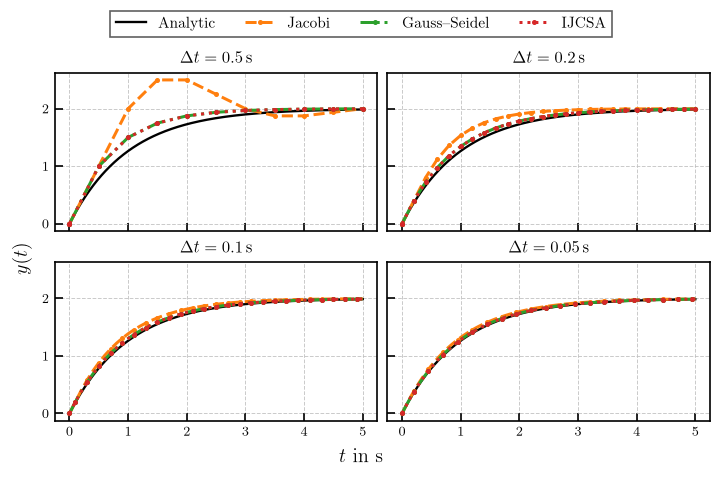

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, str(Path.cwd().parents[0] / "figures"))
from plot_setup import set_professional_style, FULL_WIDTH
set_professional_style(latex=True, fontsize=10)

step_sizes = [0.5, 0.2, 0.1, 0.05]

fig, axes = plt.subplots(
    2, 2,
    figsize=(FULL_WIDTH, FULL_WIDTH * 0.6),
    sharex=True, sharey=True,
    constrained_layout=True,
)

for ax, dt in zip(axes.flat, step_sizes):
    ax.plot(t_ref, y_ref, label="Analytic", color="black", linewidth=1.4)

    step = max(1, int(0.25 / dt))
    for algo, style in [("Jacobi", ("C1", "--")),
                        ("Gauss--Seidel", ("C2", "-.")),
                        ("IJCSA", ("C3", ":"))]:
        t_vals, y_vals = results[(algo.replace("--", "-"), dt)]
        color, ls = style
        ax.plot(t_vals, y_vals, linestyle=ls, color=color,
                marker=".", markevery=step, label=algo)

    ax.set_title(rf"$\Delta t = {dt}\,\mathrm{{s}}$")
    ax.grid(True)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4,
           bbox_to_anchor=(0.5, 1.1))

fig.supxlabel(r"$t$ in $\mathrm{s}$")
fig.supylabel(r"$y(t)$")

out = Path.cwd() / "figures"
out.mkdir(parents=True, exist_ok=True)
fig.savefig(out / "01_algorithm_comparison.pdf")
plt.show()
